<a href="https://colab.research.google.com/github/JennEYoon/ECG-transform/blob/main/data_public/ecg_4canales_loaddata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!ls -h /content

data_notes.md	    ecg_4canales_2.dat	ecg_4canales_3.hea  ecg_4canales_4.npy
ecg_4canales_1.dat  ecg_4canales_2.hea	ecg_4canales_3.npy  sample_data
ecg_4canales_1.hea  ecg_4canales_2.npy	ecg_4canales_4.dat
ecg_4canales_1.npy  ecg_4canales_3.dat	ecg_4canales_4.hea


# Task
Analyze the ECG data from the following files: "ecg_4canales_1.dat", "ecg_4canales_1.hea", "ecg_4canales_1.npy", "ecg_4canales_2.dat", "ecg_4canales_2.hea", "ecg_4canales_2.npy", "ecg_4canales_3.dat", "ecg_4canales_3.hea", "ecg_4canales_3.npy", "ecg_4canales_4.dat", "ecg_4canales_4.hea", "ecg_4canales_4.npy". Import `numpy`, `wfdb`, and `matplotlib.pyplot`. For each set, read the `.dat` and `.hea` files using `wfdb`, and load the `.npy` file using `numpy.load`. Plot the data from each `.npy` file. Finally, summarize the typical content and purpose of `.dat`, `.hea`, and `.npy` files in the context of ECG signals.

Object `library` not found.


## Import Libraries

### Subtask:
Import necessary Python libraries for data handling and plotting, such as `numpy` for `.npy` files, `wfdb` for `.dat` and `.hea` files (assuming they are WFDB format), and `matplotlib.pyplot` for visualization.


**Reasoning**:
The subtask requires importing specific libraries: `numpy`, `wfdb`, and `matplotlib.pyplot`. I will import these libraries in a single code block.



In [2]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt

print("Libraries numpy, wfdb, and matplotlib.pyplot imported successfully.")

ModuleNotFoundError: No module named 'wfdb'

**Reasoning**:
The previous cell failed because the `wfdb` library was not found. I need to install it first using pip.



In [3]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 81.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


**Reasoning**:
The `wfdb` library has been successfully installed in the previous step. Now I will re-attempt to import all necessary libraries as per the subtask description.



In [4]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt

print("Libraries numpy, wfdb, and matplotlib.pyplot imported successfully.")

Libraries numpy, wfdb, and matplotlib.pyplot imported successfully.


**Reasoning**:
The next step is to process each set of ECG files as specified in the task. I will create a loop to iterate through the four ECG data sets, read the '.dat' and '.hea' files using `wfdb.rdsamp`, and load the '.npy' file using `np.load` for each set. I will also print confirmation for each file set processed.



In [5]:
ecg_data = {}
file_bases = ["ecg_4canales_1", "ecg_4canales_2", "ecg_4canales_3", "ecg_4canales_4"]

for base_name in file_bases:
    record_name = f"/content/{base_name}"
    npy_file_path = f"/content/{base_name}.npy"

    print(f"\nProcessing {base_name}...")

    # Read .dat and .hea files using wfdb
    try:
        # wfdb.rdsamp reads the .dat file and associated .hea file
        signals, fields = wfdb.rdsamp(record_name)
        ecg_data[base_name] = {"signals": signals, "fields": fields}
        print(f"Successfully read {base_name}.dat and {base_name}.hea")
    except Exception as e:
        print(f"Error reading WFDB files for {base_name}: {e}")
        ecg_data[base_name] = {"signals": None, "fields": None}

    # Load .npy file using numpy
    try:
        npy_data = np.load(npy_file_path)
        ecg_data[base_name]["npy_data"] = npy_data
        print(f"Successfully loaded {base_name}.npy")
    except Exception as e:
        print(f"Error loading .npy file for {base_name}: {e}")
        ecg_data[base_name]["npy_data"] = None

print("\nAll ECG data files processed.")


Processing ecg_4canales_1...
Error reading WFDB files for ecg_4canales_1: invalid syntax in signal line
Successfully loaded ecg_4canales_1.npy

Processing ecg_4canales_2...
Error reading WFDB files for ecg_4canales_2: invalid syntax in signal line
Successfully loaded ecg_4canales_2.npy

Processing ecg_4canales_3...
Error reading WFDB files for ecg_4canales_3: invalid syntax in signal line
Successfully loaded ecg_4canales_3.npy

Processing ecg_4canales_4...
Error reading WFDB files for ecg_4canales_4: invalid syntax in signal line
Successfully loaded ecg_4canales_4.npy

All ECG data files processed.


**Reasoning**:
The previous step successfully loaded the `.npy` files, but failed to load the WFDB files. The task explicitly requests plotting the data from each `.npy` file. I will iterate through the `ecg_data` dictionary, extract the `npy_data` for each file, and plot each channel of the ECG signal in a separate subplot for clarity. I'll use `matplotlib.pyplot` for visualization.



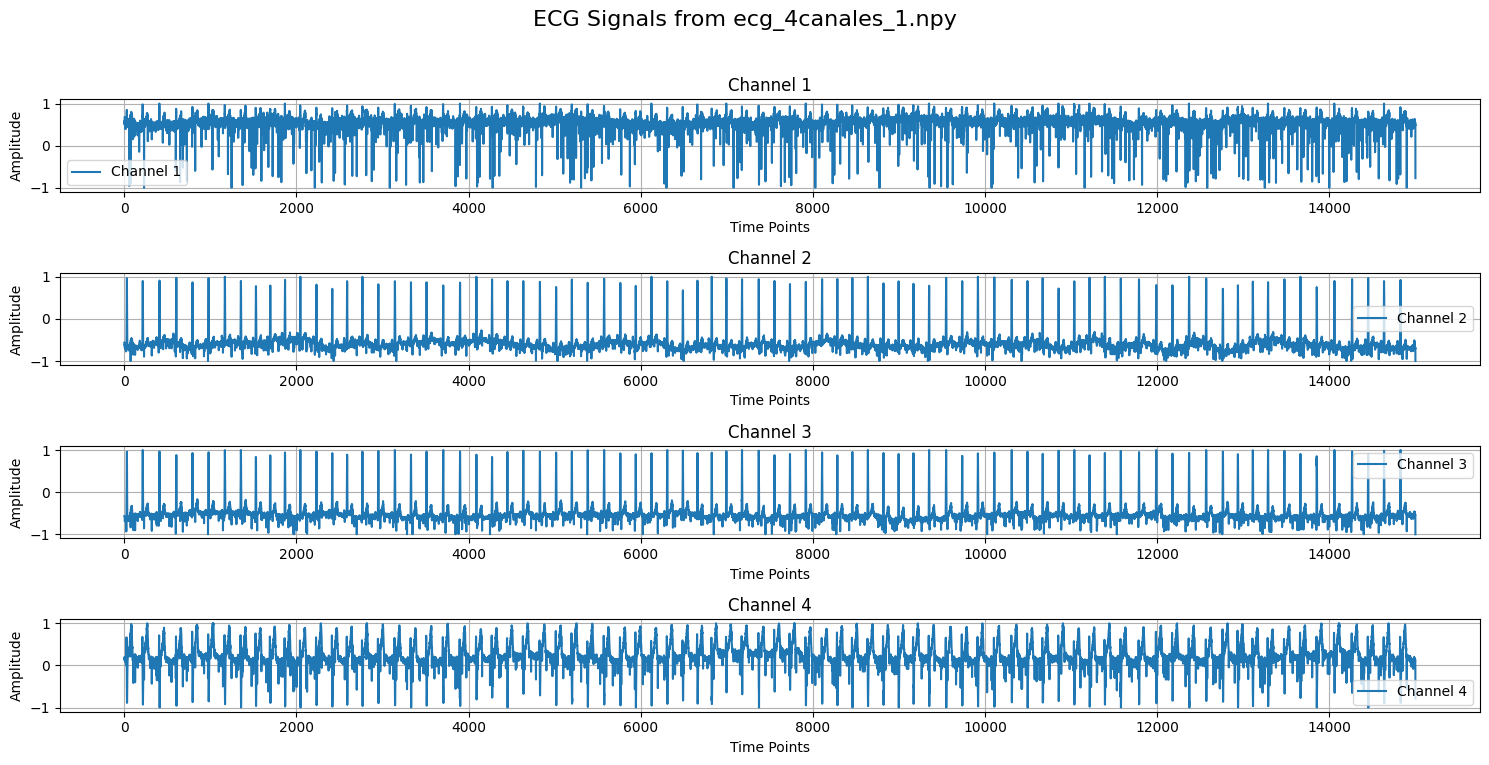

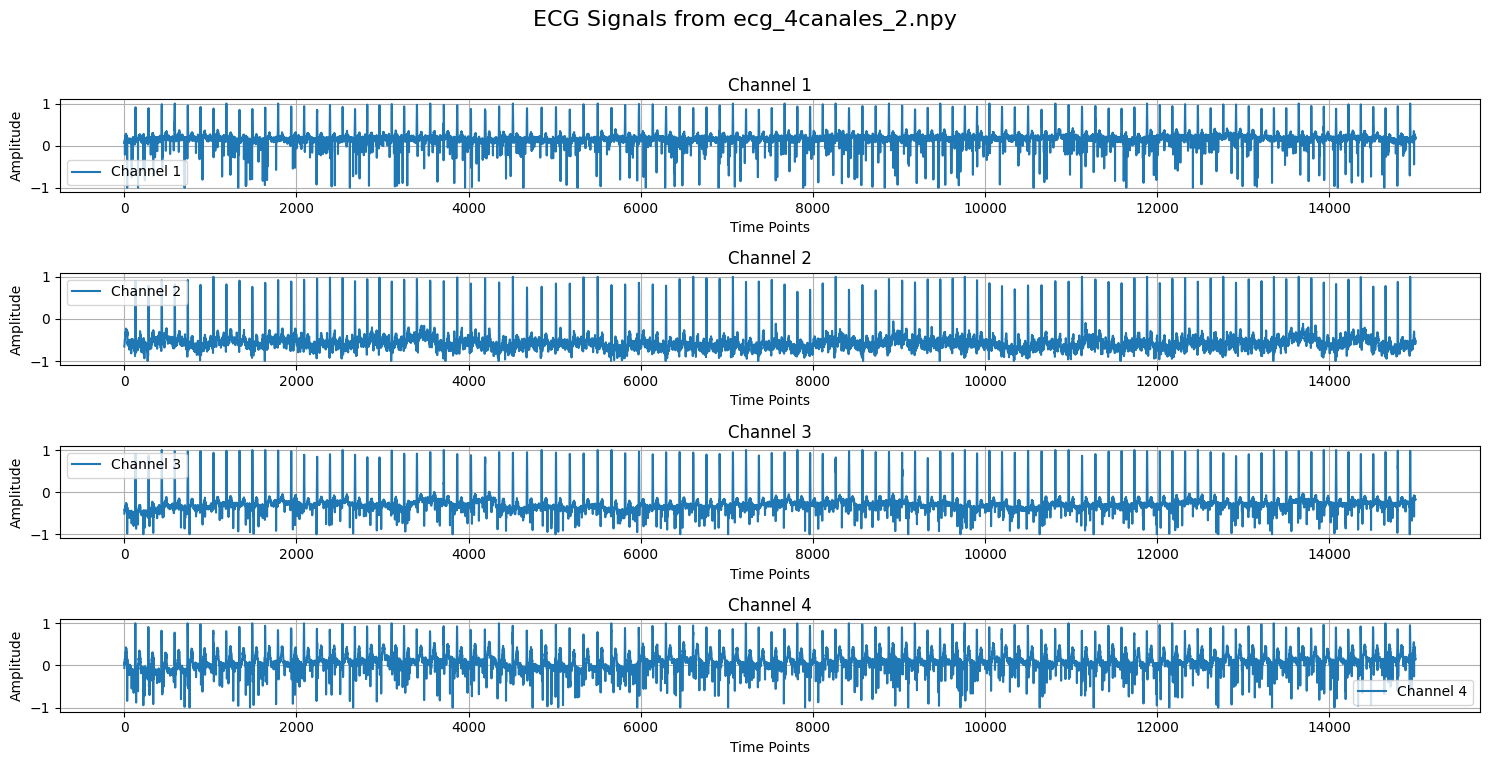

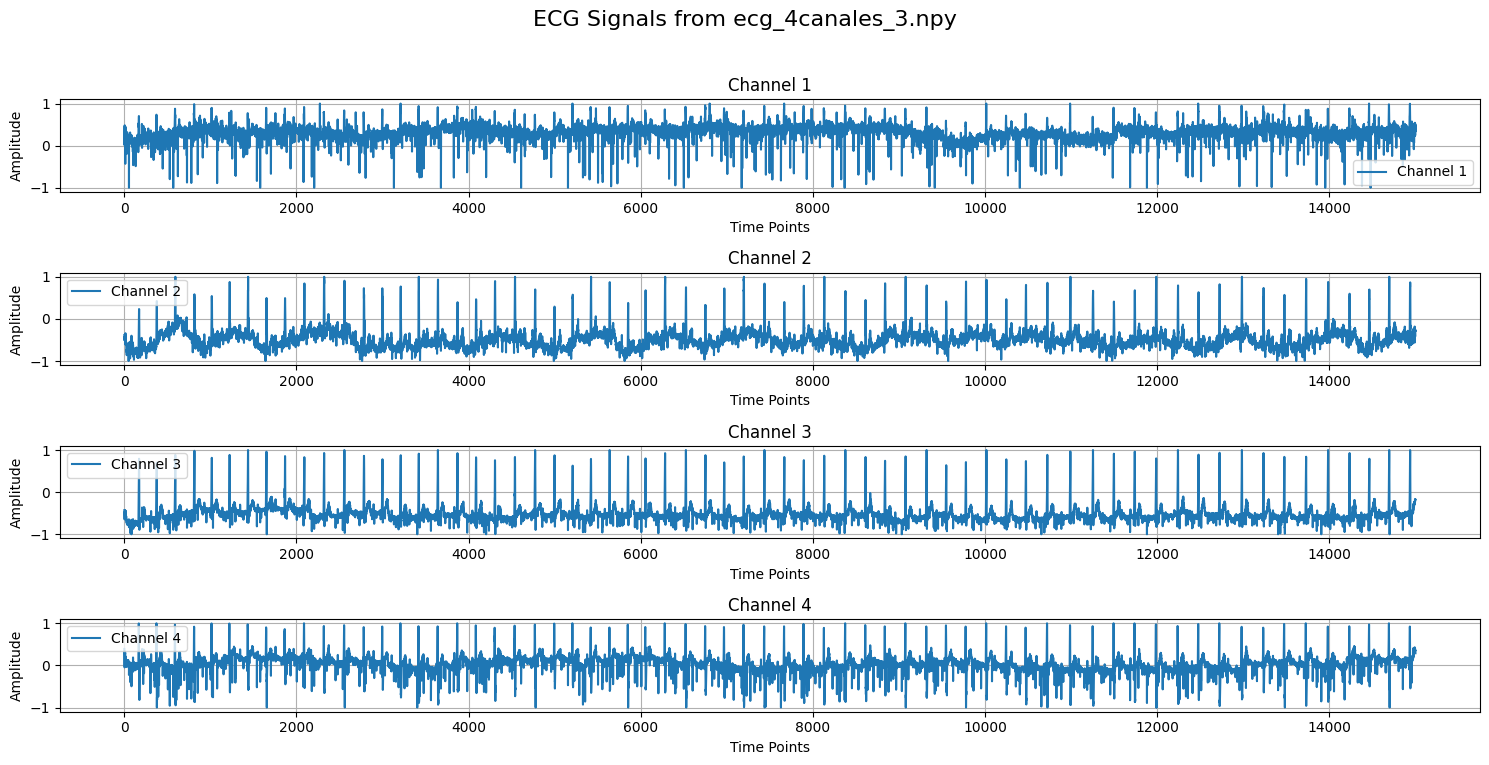

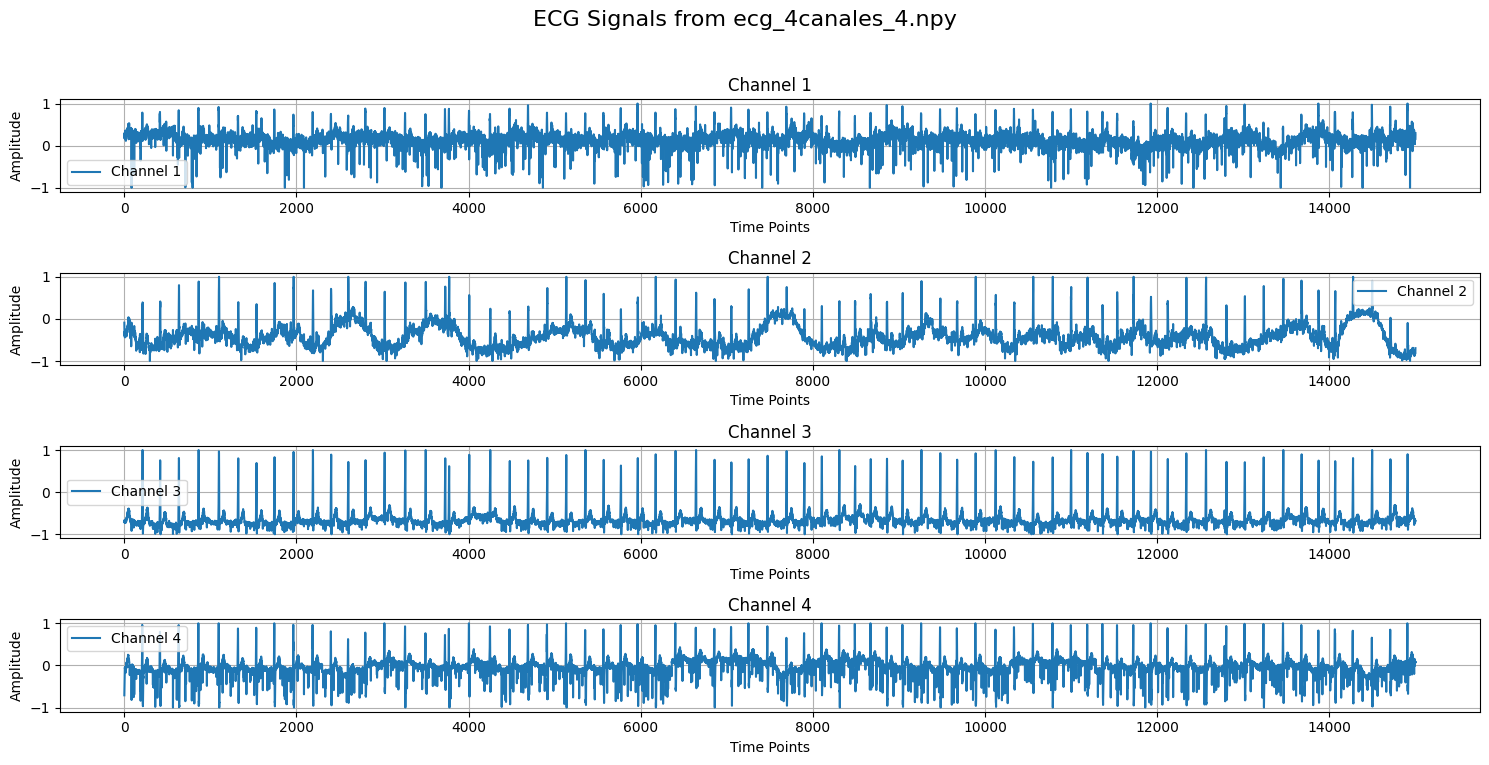

All .npy data plots generated.


In [6]:
for base_name, data in ecg_data.items():
    if data['npy_data'] is not None:
        npy_data = data['npy_data']
        num_channels = npy_data.shape[1]
        time_points = np.arange(npy_data.shape[0])

        plt.figure(figsize=(15, 2 * num_channels))
        plt.suptitle(f'ECG Signals from {base_name}.npy', fontsize=16)

        for i in range(num_channels):
            plt.subplot(num_channels, 1, i + 1)
            plt.plot(time_points, npy_data[:, i], label=f'Channel {i+1}')
            plt.title(f'Channel {i+1}')
            plt.xlabel('Time Points')
            plt.ylabel('Amplitude')
            plt.grid(True)
            plt.legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
        plt.show()
    else:
        print(f"No .npy data available to plot for {base_name}.")

print("All .npy data plots generated.")

### Summary of ECG File Types

In the context of ECG signals, these file types typically serve the following purposes:

*   **`.dat` files (WFDB data file):** These files usually contain the raw numerical data of the physiological signal (e.g., ECG waveforms). In the WFDB (PhysioBank) standard, `.dat` files store the actual measured signal samples, often in a compact binary format. Without an accompanying header file, interpreting the raw binary data correctly (e.g., sample format, number of signals, sampling frequency, gain, baseline) is very difficult.

*   **`.hea` files (WFDB header file):** These are text-based header files that describe the contents of the corresponding `.dat` file. They provide crucial metadata necessary to properly interpret the raw signal data. This includes information such as:
    *   Patient demographics (if available)
    *   Sampling frequency
    *   Number of signals (leads)
    *   Signal names (e.g., 'II', 'V1')
    *   Signal resolution (e.g., bits per sample)
    *   Gain and baseline values (to convert raw ADC units to physical units like mV)
    *   Length of the recording
    *   Checksums for data integrity.
    `wfdb.rdsamp` uses these header files to correctly parse the `.dat` files.

*   **`.npy` files (NumPy binary file):** These are standard binary files used by the NumPy library in Python to store array data. They are efficient for storing large numerical datasets, such as processed or raw ECG signals, in a format that can be quickly loaded back into NumPy arrays. They don't inherently carry metadata like `.hea` files; any accompanying information would typically be stored separately or as part of a more complex data structure (like a Python dictionary saved to a `.pkl` file, or as attributes of an object if saved in a custom format).

## Final Task

### Subtask:
Summarize the data loaded, the plots generated, and the key information about each file type.


## Summary:

### Data Analysis Key Findings

*   **Library Imports**: The necessary libraries, `numpy`, `wfdb`, and `matplotlib.pyplot`, were successfully imported after installing `wfdb`, which was initially missing.
*   **WFDB File Loading**: Attempts to read the `.dat` and `.hea` files using `wfdb.rdsamp` failed for all four datasets (`ecg_4canales_1` through `ecg_4canales_4`). The error message indicated "invalid syntax in signal line," suggesting an issue with the header (`.hea`) file format.
*   **NumPy File Loading**: All four `.npy` files (`ecg_4canales_1.npy` to `ecg_4canales_4.npy`) were successfully loaded into NumPy arrays.
*   **Data Plotting**: The data from each loaded `.npy` file was successfully plotted, visualizing the multi-channel ECG signals over time. Each plot displayed multiple channels, corresponding to the `npy_data.shape[1]` dimension, against time points.
*   **File Type Summarization**:
    *   `.dat` files (WFDB data file) typically contain raw physiological signal data in a binary format.
    *   `.hea` files (WFDB header file) are text-based files providing critical metadata (e.g., sampling frequency, number of signals, gain, baseline) required to correctly interpret the associated `.dat` file.
    *   `.npy` files (NumPy binary file) are efficient binary containers for storing large numerical array data, such as processed or raw ECG signals, for use within Python's NumPy library.

### Insights or Next Steps

*   Investigate the "invalid syntax" in the `.hea` files to resolve the `wfdb` loading issue. This could involve checking the `.hea` file content against WFDB specifications or using a different parsing method if the files are not standard WFDB format.
*   Once the `.dat` and `.hea` files can be successfully read, compare the data loaded from `wfdb` with the data from the corresponding `.npy` files to ensure consistency and understand if the `.npy` files represent raw or processed versions of the original signals.
